# Kinematic sample
This notebook compiles data from lenses with imaging data and integrated velocity dispersion measurements.

In [1]:
from hierarc.LensPosterior.kin_constraints import KinConstraints
from hierarc.Util import ifu_util
from lenstronomy.Util import constants as const
from lenstronomy.Util import param_util
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Analysis.light_profile import LightProfileAnalysis
from astropy.io import fits
import numpy as np
import pickle
import os
import csv
import matplotlib.pyplot as plt
%matplotlib inline

## Sample from SLACS


In [2]:
dir_path = os.getcwd()

# path to folder with IFU data
ifu_folder = 'slacs_kcwi_data' 
path2ifu = os.path.join(dir_path, ifu_folder)

# BOSS spectra observational conditions, https://arxiv.org/pdf/0805.1931.pdf Section 6.3
# circular apperture with diameter 3 arc seconds and seeing approx 1.4 arc seconds
kwargs_aperture_slit = {'aperture_type': 'shell', 'r_in': 0, 'r_out': 3/2., 'center_ra': 0.0, 'center_dec': 0}
kwargs_seeing_slit = {'psf_type': 'GAUSSIAN', 'fwhm': 1.4}

# numerical settings (not needed if power-law profiles with Hernquist light distribution is computed)
kwargs_numerics_galkin = {'interpol_grid_num': 1000,  # numerical interpolation, should converge -> infinity
                          'log_integration': True,  # log or linear interpolation of surface brightness and mass models
                          'max_integrate': 100, 'min_integrate': 0.001}  # lower/upper bound of numerical integrals

num_sample_model_ifu = 100  # number of draws from the model to generate a kinematic prediction for the IFU (more needed for accurate covariance calculation)
num_sample_model_slit = 100  # number of draws from the model to generate a kinematic prediction for the slit data

# anisotropy model
anisotropy_model = 'const' # 'OM', 'GOM', 'const' 

# population distribution in the power-law slope
# this distribution is assumed on lenses within the sample that do not have a reliably measured slope from imaging data


# file containing different measurements of the stellar kinematics of the SLACS lenses from SDSS, re-analyzed from Knabel et al. 2024
v_disp_file_name = 'vdisp_slacs_smk.fits'
v_disp_file = os.path.join(dir_path, v_disp_file_name)
HDU = fits.open(v_disp_file)
vel_disp_data = HDU[1].data

# file containing all the information about the sample including lens model parameters from imaging data
file_name_param_catalogue = 'slacs_all_params.csv'
file_name_param = os.path.join(dir_path, file_name_param_catalogue)
print(file_name_param)

process_ifu = False
process_slit = False


/Users/sibirrer/Science/Projects/TDCOSMO/7LensMilestone/Likelihoods/MilestoneLikelihood/ExternalLenses/SLACS/slacs_all_params.csv


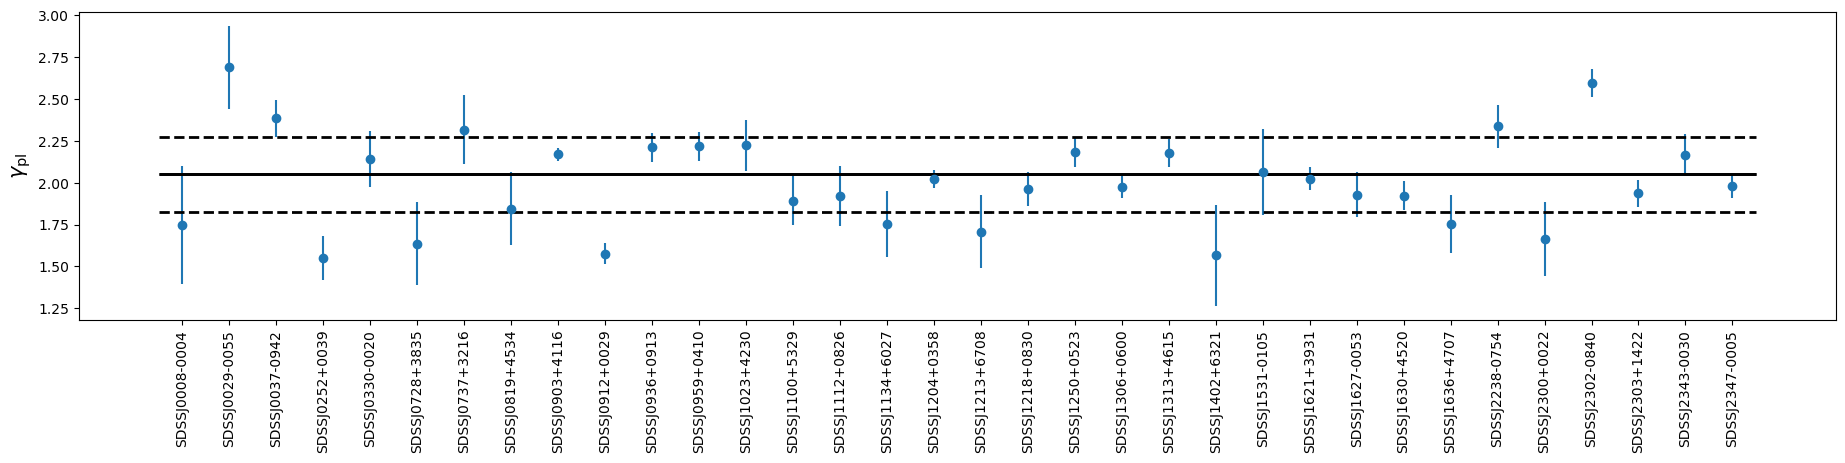

2.0503606679224946 0.22291485552700457


In [3]:
# Compute population level power-law slopes and spread
# gamma_mean_pop, gamma_error_pop = 2.10, 0.16

def gamma_pop(file_name):
    """
    estimates the population mean and Gaussian spread of the power-law slope based on lensing data only
    """
    gamma_list = []
    name_list_gamma = []
    gamma_error_list = []

    with open(file_name, newline='') as myFile:
        reader = csv.DictReader(myFile)
        for row in reader:
            name = row['name']
            flag_imaging = float(row['flag_imaging_tan23'])
            if flag_imaging == 1:
                if True:  # TODO add environmental cuts?
                    gamma = float(row['gamma'])
                    # gamma_error = float(row['gamma_error'])
                    gamma_error_sys = float(row['gamma_error_sys'])
                    gamma_error_stat = float(row['gamma_error_stat'])
                    gamma_error = np.hypot(gamma_error_sys, gamma_error_stat) # eq.(11) in Tan et al 2024
                    gamma_list.append(gamma)
                    gamma_error_list.append(gamma_error)
                    name_list_gamma.append(name)
    gamma_list = np.array(gamma_list)
    gamma_error_list = np.array(gamma_error_list)
    gamma_mean_pop = np.average(gamma_list, weights=1./ gamma_error_list**2)
    error_mean = np.sqrt(np.mean(gamma_error_list**2))  # square average error in the measurement
    gamma_sigma_pop = np.sqrt(np.var(gamma_list) - error_mean**2)  # subtract the error variance from the measured variance
    
    # make plot of distribution
    f, ax = plt.subplots(1, 1, figsize=(len(name_list_gamma)/1.5, 4))
    x = np.arange(len(name_list_gamma))
    ax.errorbar(x, gamma_list, yerr=gamma_error_list,
                    #color=color_measurement,
                    xerr=None, fmt='o', ecolor=None, elinewidth=None,
                    capsize=None, barsabove=False, lolims=False, uplims=False,
                    xlolims=False, xuplims=False, errorevery=1, capthick=None, data=None)

    ax.hlines(y=gamma_mean_pop, xmin=-0.5, xmax=len(name_list_gamma)-0.5, linewidth=2, color='k')
    ax.hlines(y=gamma_mean_pop - gamma_sigma_pop, xmin=-0.5, xmax=len(name_list_gamma)-0.5, linestyle='--', linewidth=2, color='k')
    ax.hlines(y=gamma_mean_pop + gamma_sigma_pop, xmin=-0.5, xmax=len(name_list_gamma)-0.5, linestyle='--', linewidth=2, color='k')
    ax.hlines(y=gamma_mean_pop, xmin=-0.5, xmax=len(name_list_gamma)-0.5, linewidth=2, color='k')
    ax.set_xticks(ticks=x)
    ax.set_xticklabels(labels=name_list_gamma, rotation='vertical')
    ax.set_ylabel(r'$\gamma_{\rm pl}$', fontsize=15)
    plt.show()
    
    return gamma_mean_pop, gamma_sigma_pop

gamma_mean_pop, gamma_error_pop = gamma_pop(file_name=file_name_param)
print(gamma_mean_pop, gamma_error_pop)

In [4]:

def vel_disp_sdss(name):
    """
    reads out the velocity dispersion measurements and error of SDSS spectra from the fits file. 
    Table from Shawn Knable
    """
    for lens in vel_disp_data:
        if name == lens['SDSS_NAME']:
            sigma = lens['VDISP_SMK']
            if sigma > 0:
                return lens['VDISP_SMK'], lens['VDISP_SMK_ERR']
            else:
                print('no measured dispersion from tabel' )
    print('name %s not in sample  - using SDSS standard reduction' % (name))
    return None, None


def load_ifu_kcwi(name):
    """
    load the KCWI IFU data
    
    bin_inner_edge, bin_outer_edge, binned_Vrms formato of<name>_kinmap.csv file
    the outer bin edge of the previous bin needs to match the inner bin of the next one
    
    """
    ifu_file = os.path.join(path2ifu, name, str(name+'_kinmap.csv'))
    r_outer = []
    r_inner = []
    sigma_v = []
    with open(ifu_file, newline='') as myFile:
        reader = csv.DictReader(myFile)
        #r_bins.append(reader[0]['bin_inner_edge'])
        for i, row in enumerate(reader):
            r_outer.append(float(row['bin_outer_edge']))
            r_inner.append(float(row['bin_inner_edge']))
            sigma_v.append(float(row['binned_Vrms']))
    r_bins = np.append(r_inner, r_outer[-1]) 
    sigma_v = np.array(sigma_v)
    
    # covariance matrix
    ifu_cov_file = os.path.join(path2ifu, name, str(name+'_kinmap_cov.csv'))
    
    sigma_v_cov_matrix = np.zeros((len(sigma_v), len(sigma_v)))
    with open(ifu_cov_file, "r") as f:
        reader = csv.reader(f, delimiter=",")
        for i, line in enumerate(reader):
            if i > 0:
                for j, value in enumerate(line):
                    sigma_v_cov_matrix[i-1, j] = float(value)
    
    return sigma_v, sigma_v_cov_matrix, r_bins


def light_ellipticity(row):
    """
    computes the light ellipticity from the raw in the table. This function can deal with single and double Sersic profiles
    """
    
    light_model = str(row['light_model'])
    
    if light_model == 'single_sersic':
        e1, e2 = float(row['e1_sersic1']), float(row['e2_sersic1'])
        
    elif light_model == 'double_sersic':
        r_sersic_1, n_sersic_1, e1_sersic1, e2_sersic1, amp_sersic_1 = float(row['r_sersic_1']), float(row['n_sersic_1']), float(row['e1_sersic1']), float(row['e2_sersic1']), float(row['amp_sersic_1'])
        r_sersic_2, n_sersic_2, e1_sersic2, e2_sersic2, amp_sersic_2 = float(row['r_sersic_2']), float(row['n_sersic_2']), float(row['e1_sersic2']), float(row['e2_sersic2']), float(row['amp_sersic_2'])
        e1_1, e2_2 = float(row['e1_sersic1']), float(row['e2_sersic1'])
        from lenstronomy.LightModel.light_model import LightModel
        lightModelClass = LightModel(light_model_list=['SERSIC_ELLIPSE', 'SERSIC_ELLIPSE'])
        from lenstronomy.Analysis.light_profile import LightProfileAnalysis
        lightAnalysis = LightProfileAnalysis(lightModelClass)
        kwargs_light = [{'amp': amp_sersic_1, 'R_sersic': r_sersic_1, 'n_sersic': n_sersic_1, 'e1': e1_sersic1, 'e2': e2_sersic1, 'center_x': 0, 'center_y': 0},
                        {'amp': amp_sersic_2, 'R_sersic': r_sersic_2, 'n_sersic': n_sersic_2, 'e1': e1_sersic2, 'e2': e2_sersic2, 'center_x': 0, 'center_y': 0}]
        e1, e2 = lightAnalysis.ellipticity(kwargs_light, grid_spacing=0.1, grid_num=100)
    else:
        e1, e2 = 0, 0
    phi, q = param_util.ellipticity2phi_q(e1, e2)
    return q



def process_sample_slit(file_name):
    """
    SDSS single slit (or fiber) measurement
    """
    posterior_list = []

    with open(file_name, newline='') as myFile:
        reader = csv.DictReader(myFile)
        for row in reader:
            name = row['name']
            print(name)
            flag_imaging = float(row['flag_imaging_tan23'])
            # only for testing kinematics that do not have a lens model
            try:
                theta_E = float(row['theta_E'])
                theta_E_error = float(row['theta_E']) * 0.02 # boost the uncertainty to 2% instead of using the reported value
            except ValueError:
                try:
                    theta_E = float(row['theta_E_auger']) 
                    theta_E_error = 0.02 * float(row['theta_E_auger']) 
                except ValueError:
                    print('No lens model for %s, excluded from the sample.' %name)
                    continue
            # only for testing kinematics that do not have a lens model
            try:
                r_eff = float(row['r_eff'])
            except:
                r_eff = float(row['r_eff_auger'])
            # few percent error in r_eff
            r_eff_error = r_eff * 0.05
            if flag_imaging < 0:
                pass
            else:
                if flag_imaging == 1:  
                    gamma= float(row['gamma'])
                    gamma_error_sys = float(row['gamma_error_sys'])
                    gamma_error_stat = float(row['gamma_error_stat'])
                    gamma_error = np.hypot(gamma_error_sys, gamma_error_stat) # error combined in quadrature
                else:
                    gamma, gamma_error = gamma_mean_pop, gamma_error_pop
                    print('For lens %s the population assumption on the power-law slope is used.' %name)
                kwargs = {'z_lens': float(row['z_lens']), 'z_source': float(row['z_source']),
                        'r_eff': r_eff, 'r_eff_error': r_eff_error,
                        'theta_E': theta_E, 'theta_E_error': theta_E_error,
                        'gamma': gamma, 'gamma_error': gamma_error}
                # MGE light models if available
                light_model = str(row['light_model'])
                if light_model == 'double_sersic':
                    r_sersic_1, n_sersic_1, amp_sersic_1, r_sersic_2, n_sersic_2, amp_sersic_2 = float(row['r_sersic_1']), float(row['n_sersic_1']), float(row['amp_sersic_1']), float(row['r_sersic_2']), float(row['n_sersic_2']), float(row['amp_sersic_2'])
                    kwargs_lens_light = [{'R_sersic': r_sersic_1, 'amp': amp_sersic_1, 'n_sersic': n_sersic_1}, 
                                            {'R_sersic': r_sersic_2, 'amp': amp_sersic_2, 'n_sersic': n_sersic_2}]
                    lens_light_model_list=['SERSIC', 'SERSIC']
                    MGE_light = True
                    kwargs_mge_light = {'grid_spacing': 0.01, 'grid_num': 100, 'n_comp': 20, 'center_x': 0., 'center_y': 0.}
                    print('MGE is active for %s' % name)
                elif light_model == 'single_sersic':
                    r_sersic_1, n_sersic_1, amp_sersic_1 = float(row['r_sersic_1']), float(row['n_sersic_1']), float(row['amp_sersic_1'])
                    kwargs_lens_light = [{'R_sersic': r_sersic_1, 'amp': amp_sersic_1, 'n_sersic': n_sersic_1}]
                    lens_light_model_list=['SERSIC']
                    MGE_light = True
                    kwargs_mge_light = {'grid_spacing': 0.01, 'grid_num': 100, 'n_comp': 20, 'center_x': 0., 'center_y': 0.}
                    print('MGE is active for %s' % name)
                else:
                    kwargs_lens_light, MGE_light, kwargs_mge_light = None, False, None
                    lens_light_model_list=['HERNQUIST']
                    
                sigma_v, sigma_v_error_independent = vel_disp_sdss(name=name)
                if sigma_v is None:
                    sigma_v = float(row['sigma_v'])
                    sigma_v_error_independent = float(row['sigma_v_error'])
                sigma_v = [sigma_v]
                sigma_v_error_independent = [sigma_v_error_independent]

                kin_constraints = KinConstraints(sigma_v_measured=sigma_v, 
                                sigma_v_error_independent=sigma_v_error_independent, 
                                sigma_v_error_covariant=0, 
                                kwargs_aperture=kwargs_aperture_slit, kwargs_seeing=kwargs_seeing_slit, 
                                kwargs_numerics_galkin=kwargs_numerics_galkin,
                                hernquist_approx=False,
                                anisotropy_model=anisotropy_model, kwargs_lens_light=kwargs_lens_light, 
                                lens_light_model_list=lens_light_model_list, MGE_light=MGE_light,
                                kwargs_mge_light=kwargs_mge_light, num_kin_sampling=2000, num_psf_sampling=100, **kwargs)

                kwargs_posterior = kin_constraints.hierarchy_configuration(num_sample_model=num_sample_model_slit)
                kwargs_posterior['flag_imaging'] = flag_imaging
                kwargs_posterior['name'] = name
                q_light = light_ellipticity(row)
                try:
                    e1_mass, e2_mass = float(row['e1_mass']), float(row['e2_mass'])
                    q_mass = param_util.ellipticity2phi_q(e1_mass, e2_mass)[1]
                except:
                    q_mass = -1 # TODO: better value?
                kwargs_posterior['kwargs_lens_properties'] = {'theta_E': theta_E,
                                                            'gamma': gamma,
                                                            'r_eff': r_eff,
                                                            'q_light': q_light,
                                                            'q_mass': q_mass}
                posterior_list.append(kwargs_posterior)
    return posterior_list




def process_sample_ifu(file_name):
    posterior_list = []

    with open(file_name, newline='') as myFile:
        reader = csv.DictReader(myFile)
        for row in reader:
            try:
                flag_ifu = int(float(row['flag_ifu_kcwi']))
            except:
                flag_ifu = -1
            if flag_ifu == 1:
                name = row['name']
                flag_imaging = float(row['flag_imaging_tan23'])
                # if the imaging data leads to a good lens model we use this model, otherwise we make use of the sample distribution
                if flag_imaging == 1:
                    gamma = float(row['gamma'])
                    gamma_error_sys = float(row['gamma_error_sys'])
                    gamma_error_stat = float(row['gamma_error_stat'])
                    gamma_error = np.hypot(gamma_error_sys, gamma_error_stat) 
                else:
                    gamma, gamma_error = gamma_mean_pop, gamma_error_pop
                    print('even with flag=1 no gamma values for %s' %name) 
                # only for testing kinematics that do not have a lens model
                try:
                    r_eff = float(row['r_eff'])
                except:
                    r_eff = float(row['r_eff_auger'])
                # only for testing kinematics that do not have a lens model
                try:
                    theta_E = float(row['theta_E'])
                    theta_E_error = float(row['theta_E']) * 0.02 # boost the uncertainty to 2% instead of using the reported value
                except:
                    theta_E = float(row['theta_E_auger'])
                    theta_E_error = float(row['theta_E_auger']) * 0.02
                # few percent error in r_eff
                r_eff_error = r_eff * 0.05
                print(name)
                sigma_v_measured, sigma_v_error_cov_matrix, r_bins = load_ifu_kcwi(name) 
                z_lens = float(row['z_lens'])

                kwargs_aperture = {'aperture_type': 'IFU_shells', 'r_bins': r_bins,  'center_ra': 0, 'center_dec': 0}
                kwargs_seeing = {'psf_type': 'GAUSSIAN', 'fwhm': float(row['psf_ifu_kcwi'])}

                kwargs = {'z_lens': float(row['z_lens']), 'z_source': float(row['z_source']),
                        'r_eff': r_eff, 'r_eff_error': r_eff_error,
                        'theta_E': theta_E, 'theta_E_error': theta_E_error,
                        'gamma': gamma, 'gamma_error': gamma_error}
                # MGE light models if available
                light_model = str(row['light_model'])
                if light_model == 'double_sersic':
                    r_sersic_1, n_sersic_1, amp_sersic_1, r_sersic_2, n_sersic_2, amp_sersic_2 = float(row['r_sersic_1']), float(row['n_sersic_1']), float(row['amp_sersic_1']), float(row['r_sersic_2']), float(row['n_sersic_2']), float(row['amp_sersic_2'])
                    kwargs_lens_light = [{'R_sersic': r_sersic_1, 'amp': amp_sersic_1, 'n_sersic': n_sersic_1}, 
                                            {'R_sersic': r_sersic_2, 'amp': amp_sersic_2, 'n_sersic': n_sersic_2}]
                    lens_light_model_list=['SERSIC', 'SERSIC']
                    MGE_light = True
                    kwargs_mge_light = {'grid_spacing': 0.01, 'grid_num': 100, 'n_comp': 20, 'center_x': 0., 'center_y': 0.}
                    print('MGE is active for %s' % name)
                elif light_model == 'single_sersic':
                    r_sersic_1, n_sersic_1, amp_sersic_1 = float(row['r_sersic_1']), float(row['n_sersic_1']), float(row['amp_sersic_1'])
                    kwargs_lens_light = [{'R_sersic': r_sersic_1, 'amp': amp_sersic_1, 'n_sersic': n_sersic_1}]
                    lens_light_model_list=['SERSIC']
                    MGE_light = True
                    kwargs_mge_light = {'grid_spacing': 0.01, 'grid_num': 100, 'n_comp': 20, 'center_x': 0., 'center_y': 0.}
                    print('MGE is active for %s' % name)
                else:
                    kwargs_lens_light, MGE_light, kwargs_mge_light = None, False, None
                    lens_light_model_list=['HERNQUIST']

                gamma_pl_scaling_array = np.linspace(start=1.5, stop=2.5, num=5)

                ifu_kin = KinConstraints(sigma_v_measured=sigma_v_measured, 
                                    sigma_v_error_cov_matrix=sigma_v_error_cov_matrix,
                                    kwargs_aperture=kwargs_aperture, kwargs_seeing=kwargs_seeing, 
                                    kwargs_numerics_galkin=kwargs_numerics_galkin, 
                                    hernquist_approx=False,
                                    anisotropy_model=anisotropy_model, kwargs_lens_light=kwargs_lens_light, 
                                    lens_light_model_list=lens_light_model_list, MGE_light=MGE_light,
                                    kwargs_mge_light=kwargs_mge_light, num_kin_sampling=2000, num_psf_sampling=500, gamma_pl_scaling=gamma_pl_scaling_array, **kwargs)

                kwargs_posterior = ifu_kin.hierarchy_configuration(num_sample_model=num_sample_model_ifu)
                kwargs_posterior['flag_ifu'] = flag_ifu
                kwargs_posterior['flag_imaging'] = flag_imaging
                kwargs_posterior['name'] = name
                q_light = light_ellipticity(row)
                try:
                    e1_mass, e2_mass = float(row['e1_mass']), float(row['e2_mass'])
                    q_mass = param_util.ellipticity2phi_q(e1_mass, e2_mass)[1]
                except:
                    q_mass = -1 # TODO: better value?
                kwargs_posterior['kwargs_lens_properties'] = {'theta_E': theta_E,
                                                            'gamma': gamma,
                                                            'r_eff': r_eff,
                                                            'q_light': q_light,
                                                            'q_mass': q_mass}
                posterior_list.append(kwargs_posterior)
    return posterior_list


In [5]:
file_name_slit = 'slacs_sdss_' + anisotropy_model + '_processed.pkl'
file_name_ifu = 'slacs_kcwi_' + anisotropy_model + '_processed.pkl'


if process_slit is True:
    posterior_list_slit = process_sample_slit(file_name_param)
    file = open(file_name_slit, 'wb')
    pickle.dump(posterior_list_slit, file)
    file.close()

            
if process_ifu is True:
    posterior_list_ifu = process_sample_ifu(file_name_param)
    file = open(file_name_ifu, 'wb')
    pickle.dump(posterior_list_ifu, file)
    file.close()
  

## Testing individual KCWI data

From here onwards, we are individually infering the posteriors of the lenses and make tests of the cuts. None of the scripts below are directly going into the joint analysis, but are meant for diagnostics.

In [6]:
# load ifu files
file = open(file_name_ifu, 'rb')
slacs_ifu_likelihood_processed = pickle.load(file)
file.close()


In [7]:
cosmology = 'FLCDM'  # available models: 'FLCDM', "FwCDM", "w0waCDM", "oLCDM"
# parameters are: 'h0', 'om', 'ok', 'w', 'w0', 'wa'

num_distribution_draw = 200

n_walkers = 100
n_run = 100  # 200
n_burn = 100  # 400


log_scatter = True  # flat prior in log space

# there is also the option to sample the post-newtonian parameter gamma_ppn

beta_inf_min, beta_inf_max = 0, 1

if anisotropy_model == 'OM':
    a_ani_min, a_ani_max, a_ani_mean = 0.1, 5, 1
if anisotropy_model == 'const':
    a_ani_min, a_ani_max, a_ani_mean = -0.49, 1, 0


kwargs_lower_cosmo = {'h0': 0, 'om': 0.05}
kwargs_lower_lens = {'lambda_mst': 0.5, 'lambda_mst_sigma': 0.001, 'alpha_lambda': -1, 'gamma_pl_list': np.ones(10) * 1.1}
kwargs_lower_kin = {'a_ani': a_ani_min, 'a_ani_sigma': 0.01, 'beta_inf': beta_inf_min, 'beta_inf_sigma': 0.001, 'sigma_v_sys_error': 0.01}
kwargs_lower_los = [{'mean': -0.1, 'sigma': 0.}]


kwargs_upper_cosmo = {'h0': 150, 'om': 0.5}
kwargs_upper_lens = {'lambda_mst': 1.5, 'lambda_mst_sigma': .5, 'alpha_lambda': 1, 'gamma_pl_list': np.ones(10)*2.9}
kwargs_upper_kin = {'a_ani': a_ani_max, 'a_ani_sigma': 1. ,'beta_inf': beta_inf_max, 'beta_inf_sigma': 1, 'sigma_v_sys_error': 0.5}
kwargs_lower_los = [{'mean': 0.2, 'sigma': 1.}]

# these values are held fixed throughout the entire sampling (optinal to add here)
kwargs_fixed_cosmo = {'h0': 70, 'om': 0.30}
kwargs_fixed_lens = {}

# for the 'GOM' model is beta_inf should be free or fixed=1
kwargs_fixed_kin = {}


kwargs_mean_start = {'kwargs_cosmo': {'h0': 70, 'om': 0.3},
                     'kwargs_lens': {'lambda_mst': 1., 'lambda_mst_sigma': .05, 'alpha_lambda': 0, 'gamma_pl_list': np.ones(10)* 2},
                     'kwargs_kin': {'a_ani': a_ani_mean, 'a_ani_sigma': 0.1, 'beta_inf': 0.8, 'beta_inf_sigma': 0.1, 'sigma_v_sys_error': 0.05}}

kwargs_sigma_start = {'kwargs_cosmo': {'h0': 10, 'om': 0.1},
                     'kwargs_lens': {'lambda_mst': .1, 'lambda_mst_sigma': .05, 'alpha_lambda': 0.1, 'gamma_pl_list': np.ones(10)*0.05},
                     'kwargs_kin': {'a_ani': 0.3, 'a_ani_sigma': 0.1, 'beta_inf': 0.5, 'beta_inf_sigma': 0.1, 'sigma_v_sys_error': 0.05}}


class CustomPrior(object):
    def __init__(self, om_prior=True, log_scatter=False):
        self._om_prior = om_prior
        self._log_scatter = log_scatter
        self.om_mean = 0.298
        self.sigma_om = 0.022
        
    def __call__(self, kwargs_cosmo, kwargs_lens, kwargs_kin, kwargs_los):
        return self.log_likelihood(kwargs_cosmo, kwargs_lens, kwargs_kin, kwargs_los)
    
    def log_likelihood(self, kwargs_cosmo, kwargs_lens, kwargs_kin, kwargs_los):

        logL = 0
        # a prior on Omega_m helps in constraining the MST parameter as the kinematics becomes less cosmology dependent...
        if self._om_prior is True:
            om = kwargs_cosmo.get('om', self.om_mean)
            logL += -(om - self.om_mean)**2 / self.sigma_om**2 / 2
    
        # a_ani = kwargs_kin.get('a_ani', 1)
        #logL += np.log(1/a_ani)
        return logL
    
kwargs_bounds = {'kwargs_lower_cosmo': kwargs_lower_cosmo,
                'kwargs_lower_lens': kwargs_lower_lens,
                'kwargs_lower_kin': kwargs_lower_kin,
                'kwargs_upper_cosmo': kwargs_upper_cosmo,
                'kwargs_upper_lens': kwargs_upper_lens,
                'kwargs_upper_kin': kwargs_upper_kin,
                'kwargs_fixed_cosmo': kwargs_fixed_cosmo,
                'kwargs_fixed_lens': kwargs_fixed_lens,
                'kwargs_fixed_kin': kwargs_fixed_kin}


SDSSJ0029-0055


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:43<00:00,  4.58it/s]


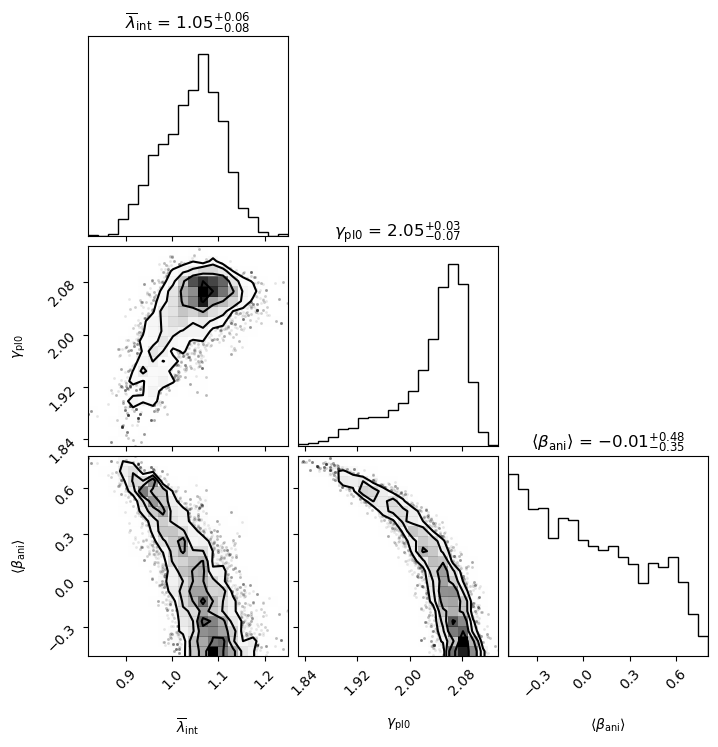

2.1627292325927567 reduced chi2

SDSSJ0037-0942


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_56569/1039698781.py:77: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:42<00:00,  4.68it/s]


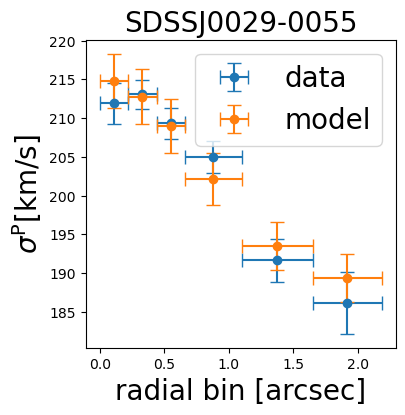

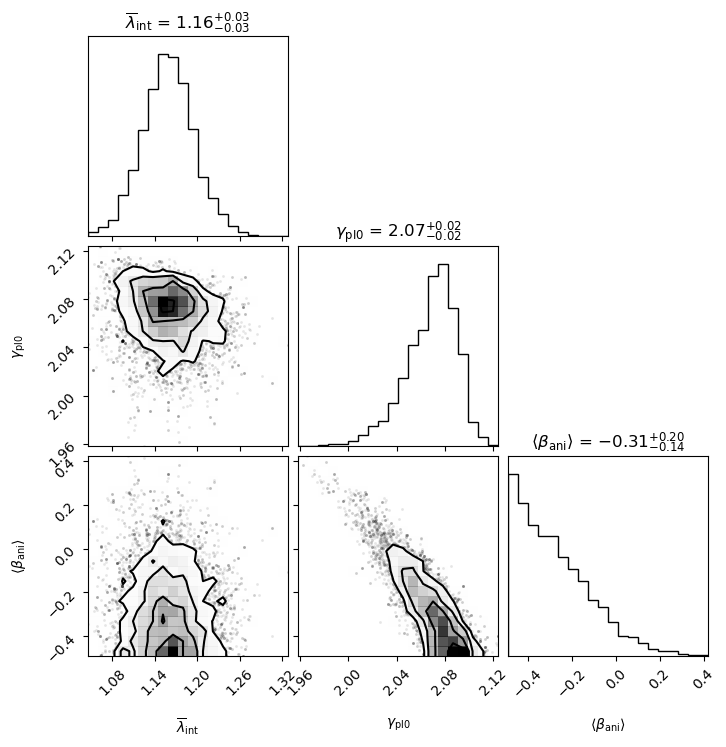

2.4722794578625376 reduced chi2

SDSSJ1112+0826


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_56569/1039698781.py:77: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:48<00:00,  4.09it/s]


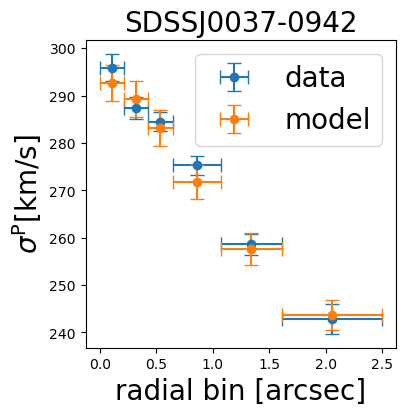

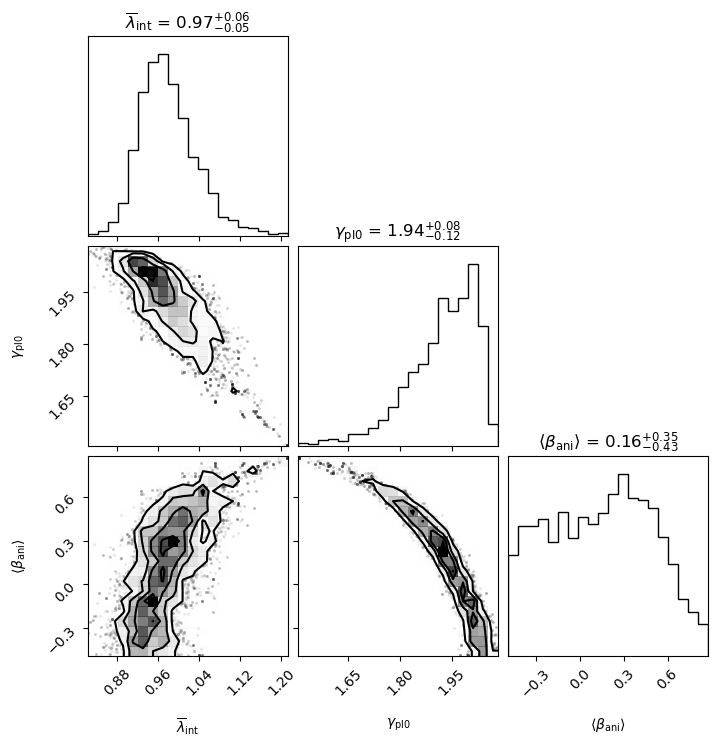

1.5723004598956145 reduced chi2

SDSSJ1204+0358


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_56569/1039698781.py:77: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:46<00:00,  4.33it/s]


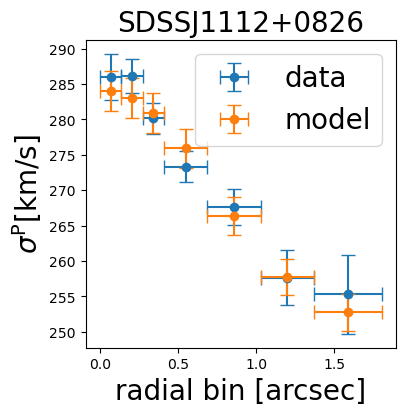

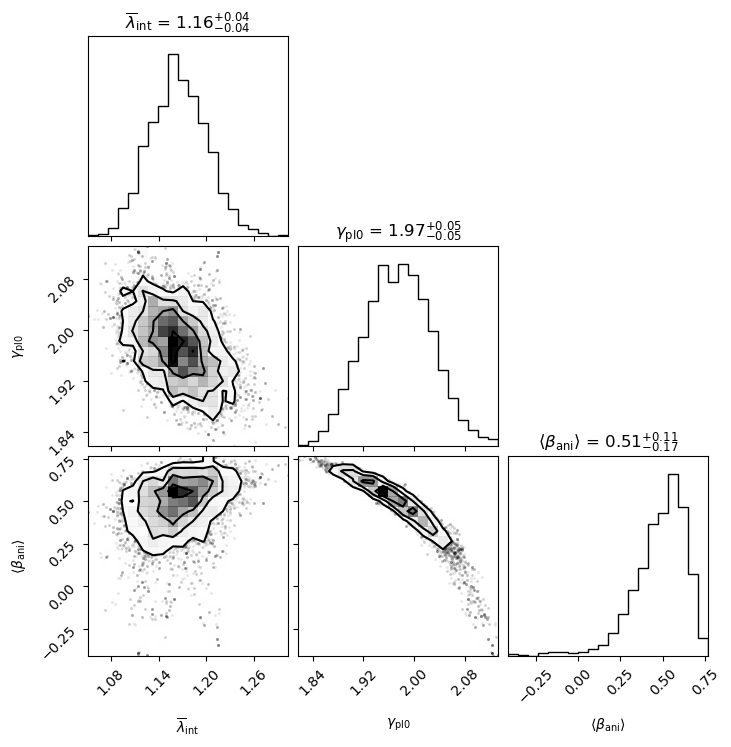

2.762968718407023 reduced chi2

SDSSJ1250+0523


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_56569/1039698781.py:77: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:42<00:00,  4.68it/s]


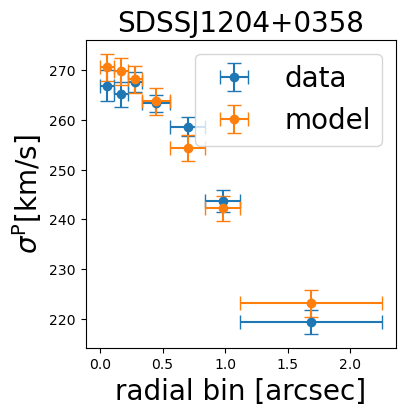

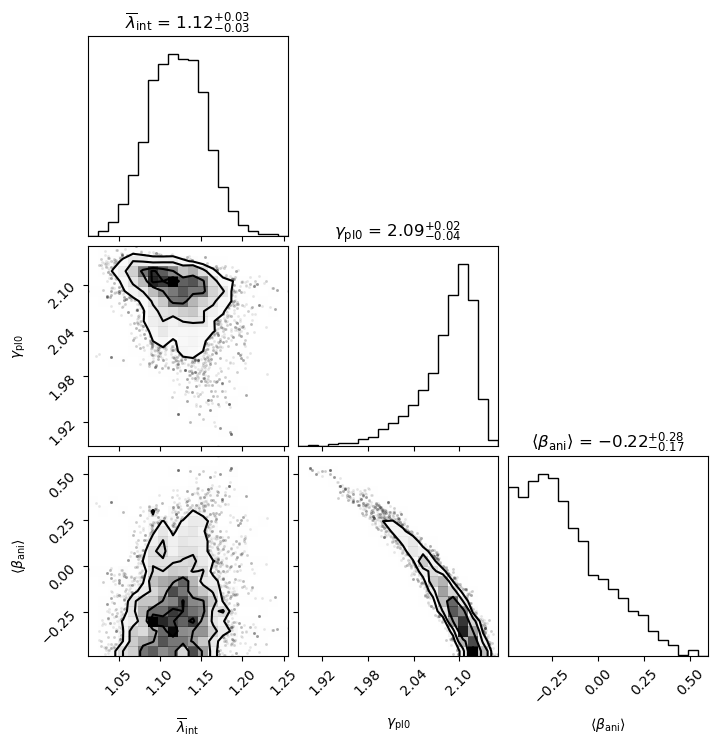

1.7640996213406843 reduced chi2

SDSSJ1306+0600


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_56569/1039698781.py:77: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:43<00:00,  4.57it/s]


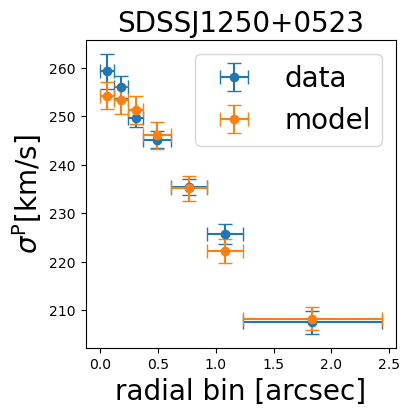

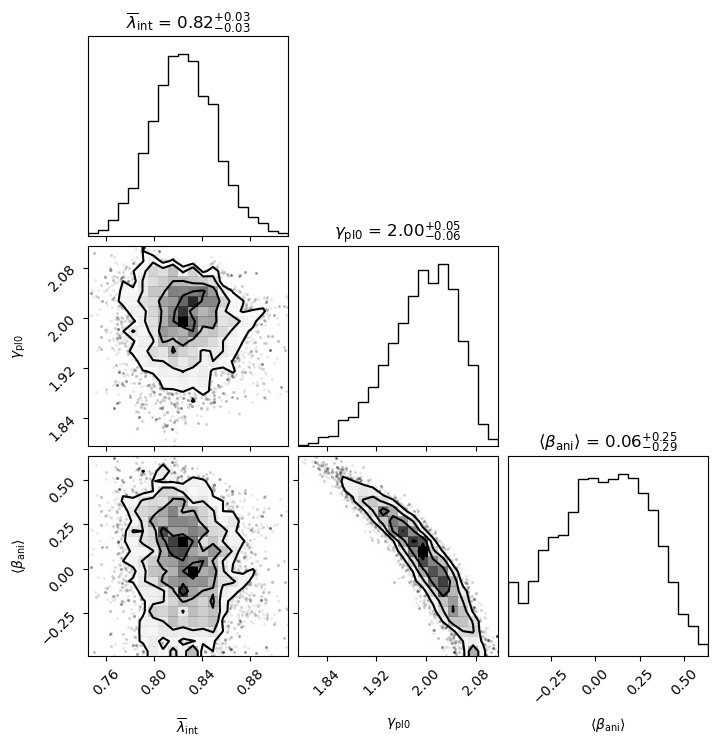

0.5274706411958404 reduced chi2

SDSSJ1402+6321


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_56569/1039698781.py:77: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:43<00:00,  4.64it/s]


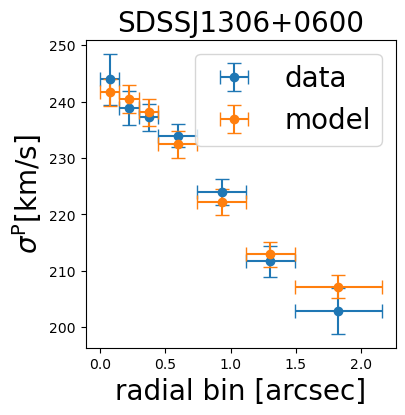

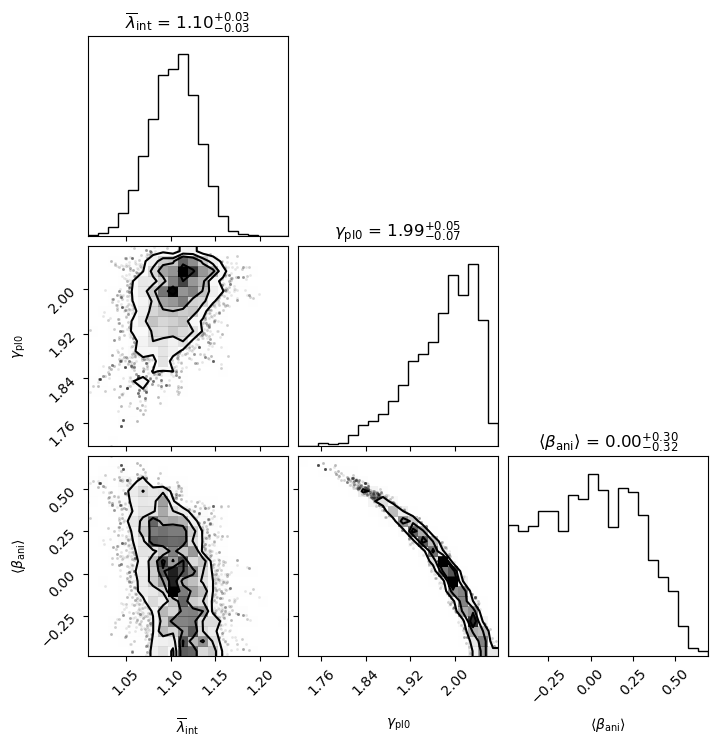

2.4630546173531047 reduced chi2

SDSSJ1531-0105


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_56569/1039698781.py:77: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:41<00:00,  4.87it/s]


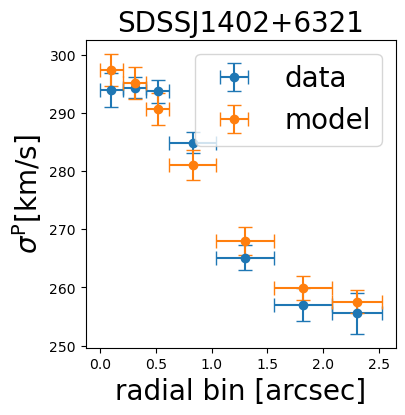

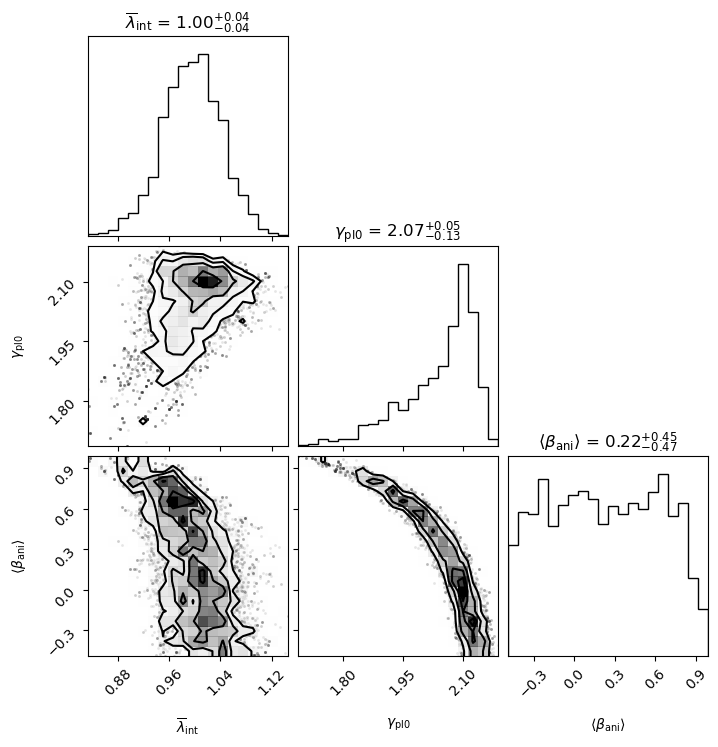

0.8064851085587496 reduced chi2

SDSSJ1621+3931


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_56569/1039698781.py:77: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:43<00:00,  4.59it/s]


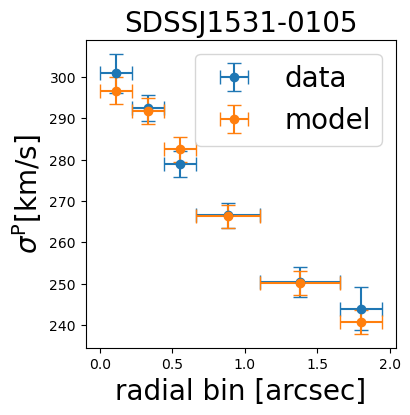

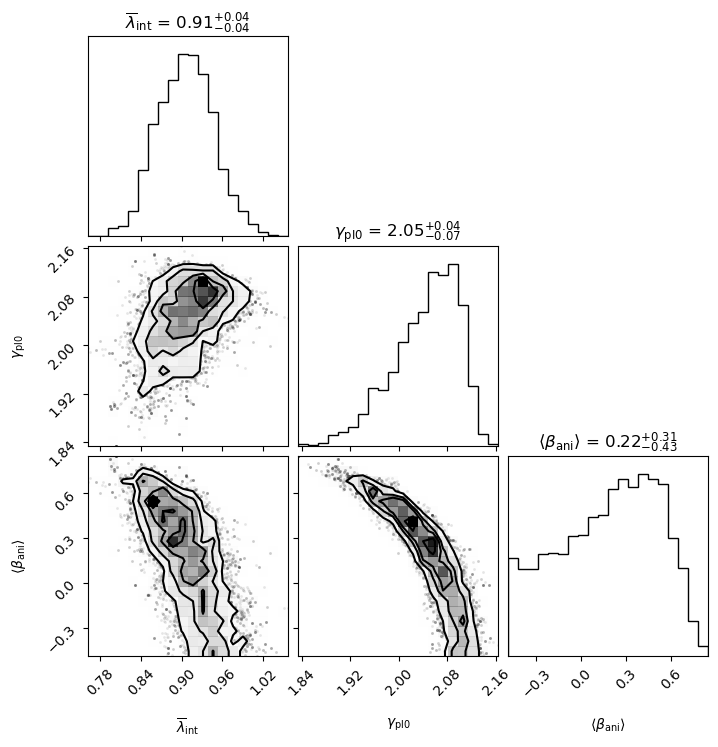

0.8915178643620557 reduced chi2

SDSSJ1627-0053


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_56569/1039698781.py:77: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:42<00:00,  4.71it/s]


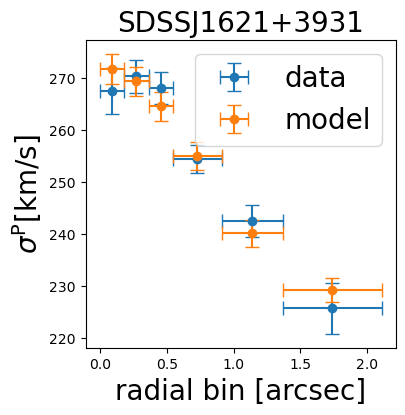

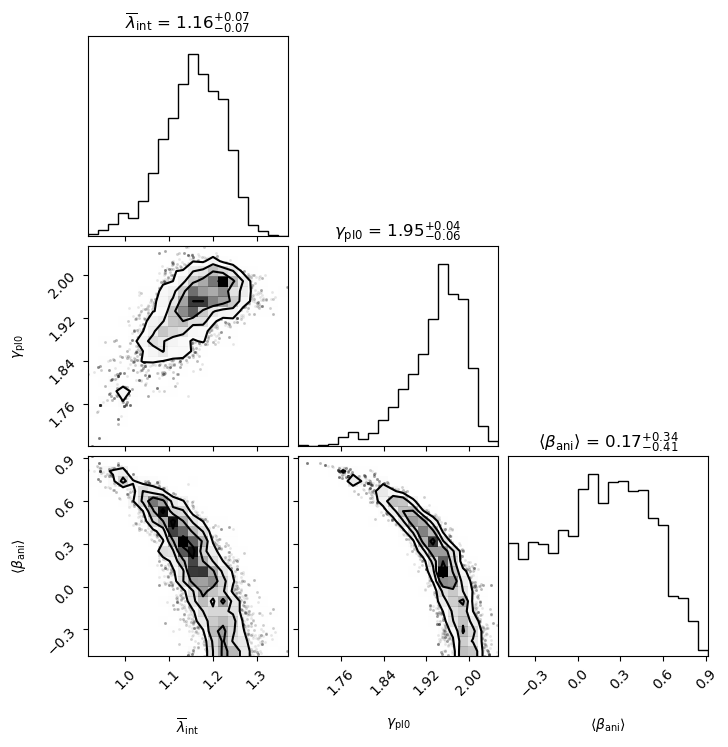

0.4493391049073126 reduced chi2

SDSSJ1630+4520


/var/folders/yp/rr1r4kgd2f3fpggf8vqnkqym0000gn/T/ipykernel_56569/1039698781.py:77: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()
 66%|█████████████████████████████████████████████████████████████████████████████████████████▊                                             | 133/200 [00:28<00:14,  4.72it/s]

In [ ]:
# here we sample the SLAC KCWI data with free lambda_mst and anisotropy
# this is for testing and reproducibility purpose only, as well as whether the data can be described by the model
from hierarc.Sampling.mcmc_sampling import MCMCSampler
import corner
from hierarc.Diagnostics.blinding import blind_posterior
from hierarc.Diagnostics.goodness_of_fit import GoodnessOfFit


lenses_test_list = ['SDSSJ0029-0055', 'SDSSJ0037-0942', 'SDSSJ1112+0826', 'SDSSJ1204+0358', 'SDSSJ1250+0523', 'SDSSJ1306+0600', 'SDSSJ1402+6321', 'SDSSJ1531-0105', 'SDSSJ1621+3931', 'SDSSJ1627-0053', 'SDSSJ1630+4520'] 

lambda_int_list = []
lambda_int_sigma_list = []
thetaE_r_eff_list = []

kwargs_model = {'lambda_mst_sampling': True,
                      'lambda_mst_distribution': 'None',
                      'anisotropy_sampling': True,
                      'anisotropy_model': anisotropy_model,
                      'anisotropy_distribution': 'NONE',
                        }

kwargs_sampler = {'kwargs_model': kwargs_model,
                      'cosmology': cosmology,
                      'interpolate_cosmo': True, 
                      'num_redshift_interp': 100,
                      'custom_prior': None,
                      'kwargs_bounds': kwargs_bounds, 
                      'cosmo_fixed': None
                      }


for i in range(len(slacs_ifu_likelihood_processed)):
    # subselect a list of lenses
    if slacs_ifu_likelihood_processed[i]['name'] in lenses_test_list:

        print(slacs_ifu_likelihood_processed[i]['name'])
        try:
            del slacs_ifu_likelihood_processed[i]['flag_ifu']
        except:
            pass
        try:
            del slacs_ifu_likelihood_processed[i]['flag_imaging']
        except:
            pass
        mcmc_sampler_slac_kcwi_single = MCMCSampler([slacs_ifu_likelihood_processed[i]],   
                                                    **kwargs_sampler
                                                )
        
        mcmc_samples_slac_kcwi_single, log_prob_single = mcmc_sampler_slac_kcwi_single.mcmc_emcee(n_walkers, n_run, n_burn, kwargs_mean_start, kwargs_sigma_start)
            
        # blind posterior
        lambda_int_list.append(np.mean(mcmc_samples_slac_kcwi_single[:, 0]))
        lambda_int_sigma_list.append(np.std(mcmc_samples_slac_kcwi_single[:, 0]))
        properties = slacs_ifu_likelihood_processed[i]['kwargs_lens_properties']
        thetaE_r_eff_list.append(properties['theta_E'] / properties['r_eff'])
        posterior_blinded = blind_posterior(mcmc_samples_slac_kcwi_single, mcmc_sampler_slac_kcwi_single.param_names(latex_style=False))
        corner.corner(mcmc_samples_slac_kcwi_single, show_titles=True, labels=mcmc_sampler_slac_kcwi_single.param_names(latex_style=True))
        plt.show()

        # get best fit
        index_best_fit = np.where(log_prob_single == np.max(log_prob_single))
        kwargs_cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, _, kwargs_los_best_fit = mcmc_sampler_slac_kcwi_single.param.args2kwargs(mcmc_samples_slac_kcwi_single[index_best_fit[0][0]])
        cosmo_best_fit = mcmc_sampler_slac_kcwi_single.param.cosmo(kwargs_cosmo_best_fit)

        # goodness of fit of kinematics
        gof = GoodnessOfFit([slacs_ifu_likelihood_processed[i]], kwargs_model = kwargs_model)
        red_chi2 = gof.reduced_chi2(cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit)
        print(red_chi2, 'reduced chi2' + '\n')

        # here we plot the IFU fit in case the data comes in this format
        # TODO: import bin edges (try to keep them saved) Current solution only works for one IFU product
        sigma_v_measured, sigma_v_error_cov_matrix, radial_bins_kcwi = load_ifu_kcwi(name=slacs_ifu_likelihood_processed[i]['name'])
        try:
            f, ax = plt.subplots(1, 1, figsize=(4, 4))
            ax = gof.plot_ifu_fit(ax, cosmo_best_fit, kwargs_lens_best_fit, kwargs_kin_best_fit, kwargs_los=kwargs_los_best_fit, lens_index=0, bin_edges=radial_bins_kcwi, show_legend=True,
                                color_measurement=None, color_prediction=None)
            f.show()
        except:
            pass



In [ ]:
# Outliers: SDSSJ1538+5817, SDSSJ1306+0600, SDSSJ1630+4520

from lenstronomy.Cosmo.lens_cosmo import LensCosmo

plt.errorbar(x=1/np.array(thetaE_r_eff_list), y=lambda_int_list - np.mean(lambda_int_list) + 1, yerr=lambda_int_sigma_list,
            fmt='o')
plt.xlabel(r'$r_{\rm eff}/\theta_{\rm E}$')
plt.ylabel(r'$\lambda_{\rm int}$ blinded')
plt.show()

# ellipticity
q_light_list = []
sigma_v_sis_list = []
for i in range(len(slacs_ifu_likelihood_processed)):
    # subselect a list of lenses
    if slacs_ifu_likelihood_processed[i]['name'] in lenses_test_list:
        q = slacs_ifu_likelihood_processed[i]['kwargs_lens_properties']['q_light']
        theta_E = slacs_ifu_likelihood_processed[i]['kwargs_lens_properties']['theta_E']
        q_light_list.append(q)
        z_lens, z_source = slacs_ifu_likelihood_processed[i]['z_lens'], slacs_ifu_likelihood_processed[i]['z_source']
        lens_cosmo = LensCosmo(z_lens=z_lens, z_source=z_source)
        sigma_sis = lens_cosmo.sis_theta_E2sigma_v(theta_E)
        sigma_v_sis_list.append(sigma_sis)

plt.errorbar(x=q_light_list, y=lambda_int_list - np.mean(lambda_int_list) + 1, yerr=lambda_int_sigma_list,
            fmt='o')
plt.xlabel(r'$q_{\rm light}$')
plt.ylabel(r'$\lambda_{\rm int}$ blinded')
plt.show()

plt.errorbar(x=sigma_v_sis_list, y=lambda_int_list - np.mean(lambda_int_list) + 1, yerr=lambda_int_sigma_list,
            fmt='o')
plt.xlabel(r'$\sigma_{\rm SIS}$')
plt.ylabel(r'$\lambda_{\rm int}$ blinded')
plt.show()
        
# sigma_sis

# LOS selection

In [ ]:
NoverRmed_random = 1.028768  # N/r value from 100000 random patches on the sky with same survey and depth as the lenses

dir_path = os.getcwd()

file_name_slacs_los = os.path.join(dir_path, 'LineOfSightData.csv')

def NoverRmed(name):
    """
    reads out the number for N/r weigthing from the DECals data in the table for a specific lens
    """
    with open(file_name_slacs_los, newline='') as myFile:
        reader = csv.DictReader(myFile)
        for row in reader:
            if '#name' in row:
                name_row = row['#name']
                if name_row == name:
                    return float(row['NoverRmed']) / NoverRmed_random # eq.(56) in Birrer et al 2020
    print('lens with name %s not in table.' % (name))
    return -1

In [ ]:
# testing SDSS kinematics
import copy
# load ifu files
file = open(file_name_slit, 'rb')
slacs_sdss_likelihood_processed = pickle.load(file)
file.close()

# path2kappa = os.path.join(path2Analysis, path2slacs, 'kappaSLACS')
path2kappa = os.path.join(dir_path, 'kappa_ext')

def read_kappa_pdf(name, kappa_bins):
    filepath = os.path.join(path2kappa, 'kappahist_'+name+kappa_choice_ending)
    output = np.loadtxt(filepath, delimiter=' ', skiprows=1)
    kappa_sample = output[:, 0]
    kappa_weights = output[:, 1]
    kappa_pdf, kappa_bin_edges = np.histogram(kappa_sample, weights=kappa_weights, bins=kappa_bins, density=True)
    return kappa_pdf, kappa_bin_edges


# kwargs_posterior_copy['num_distribution_draws'] = num_distribution_draw
# kappa_pdf, kappa_bin_edges = read_kappa_pdf(name, kappa_bins)
# kwargs_posterior_copy['kappa_pdf'] = kappa_pdf
# kwargs_posterior_copy['kappa_bin_edges'] = kappa_bin_edges


use_quality_data_only = True

def quality_cut(likelihood_list):
    """
    
    """
    likelihood_list_cut = []
    for likelihood in likelihood_list:
        if 'flag_imaging' in likelihood:
            flag_imaging = copy.deepcopy(likelihood['flag_imaging'])
            del likelihood['flag_imaging']
        else:
            flag_imaging = 1
        if 'flag_ifu' in likelihood:
            flag_ifu = copy.deepcopy(likelihood['flag_ifu'])
            del likelihood['flag_ifu']
        else:
            flag_ifu = 1

        if use_quality_data_only is True:
            if flag_imaging < 1 or flag_ifu < 1:
                pass
            else:
                likelihood_list_cut.append(likelihood)
        else:
            likelihood_list_cut.append(likelihood)
    return likelihood_list_cut


slacs_sdss_likelihood_processed_cut = quality_cut(slacs_sdss_likelihood_processed)
print(len(slacs_sdss_likelihood_processed_cut))

from hierarc.Diagnostics.goodness_of_fit import GoodnessOfFit
from astropy.cosmology import FlatLambdaCDM



kwargs_cosmo = {'h0': 70, 'om': 0.33}
kwargs_lens = {'lambda_mst': 0.9, 'lambda_mst_sigma': .1}
kwargs_kin = {'a_ani': 1.}

cosmo = FlatLambdaCDM(H0=kwargs_cosmo['h0'], Om0=kwargs_cosmo['om'])

gof = GoodnessOfFit(slacs_sdss_likelihood_processed, kwargs_model=kwargs_model)
red_chi2 = gof.reduced_chi2(cosmo, kwargs_lens, kwargs_kin)
print(red_chi2, 'reduced chi2 all')

f, ax = gof.plot_kin_fit(cosmo, kwargs_lens, kwargs_kin, kwargs_los={}, color_measurement=None, color_prediction=None)
f.show()

gof = GoodnessOfFit(slacs_sdss_likelihood_processed_cut, kwargs_model=kwargs_model)
red_chi2 = gof.reduced_chi2(cosmo, kwargs_lens, kwargs_kin)
print(red_chi2, 'reduced chi2 selected')

f, ax = gof.plot_kin_fit(cosmo, kwargs_lens, kwargs_kin, kwargs_los={}, color_measurement=None, color_prediction=None)
f.show()